## Feature Engineering :

In [1]:
# It is the process of using domain knowledge to extract features from raw data. These features can be used to improve perfomance of ML algorithm.

 #### Feature Scaling : 

It is the technique to standardize the independent features present in the data in a fixed range.

In [2]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

# Create dataset folder in your project
target_dir = "./dataset"
os.makedirs(target_dir, exist_ok=True)

# Copy files
for file in os.listdir(path):
    shutil.copy(os.path.join(path, file), target_dir)

print("Dataset copied to:", target_dir)

Dataset copied to: ./dataset


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("dataset/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df=df.iloc[:,2:]

In [6]:
df.sample(5)

,Age,EstimatedSalary,Purchased
294,35,57000,0
139,19,25000,0
175,23,28000,0
146,27,96000,1
87,28,85000,0


#### Train Test Split

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop("Purchased",axis=1),df["Purchased"],test_size=0.3,random_state=42)

In [8]:
X_train.shape

(280, 2)

#### Standard Scaler

In [9]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
# mean of each feature column across all rows
print(scaler.mean_) 
print(scaler.scale_)
print(scaler.var_)

[3.75750000e+01 7.05892857e+04]
[1.01777813e+01 3.38878280e+04]
[1.03587232e+02 1.14838489e+09]


In [11]:
X_train_scaled,X_test

(array([[-0.84252154,  0.1301563 ],
        [ 0.04175763,  0.2777019 ],
        [ 0.72953032, -1.31579061],
        [ 1.61380949,  1.10395728],
        [ 0.82778356, -1.40431797],
        [-1.43204099, -1.25677236],
        [-0.05649561,  0.1301563 ],
        [ 0.43477059, -0.16493491],
        [-0.2530021 ,  0.01211982],
        [ 1.31904976,  2.22530386],
        [ 0.14001087,  0.74984783],
        [-1.33378775,  0.54328399],
        [ 2.00682245,  0.72033871],
        [-1.23553451, -1.43382709],
        [ 0.33651735, -0.34198963],
        [-0.94077478,  0.54328399],
        [ 0.43477059,  0.2777019 ],
        [ 0.43477059,  1.10395728],
        [ 0.82778356,  0.74984783],
        [ 0.9260368 ,  1.25150288],
        [-0.44950858, -1.25677236],
        [-1.82505395, -1.34529973],
        [ 1.12254328,  0.54328399],
        [-0.64601506, -1.64039093],
        [-0.7442683 ,  0.24819278],
        [ 1.02429004,  2.07775825],
        [-0.54776182,  1.36953936],
        [-0.05649561,  0.012

In [12]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [13]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [14]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


#### Effect of Scaling

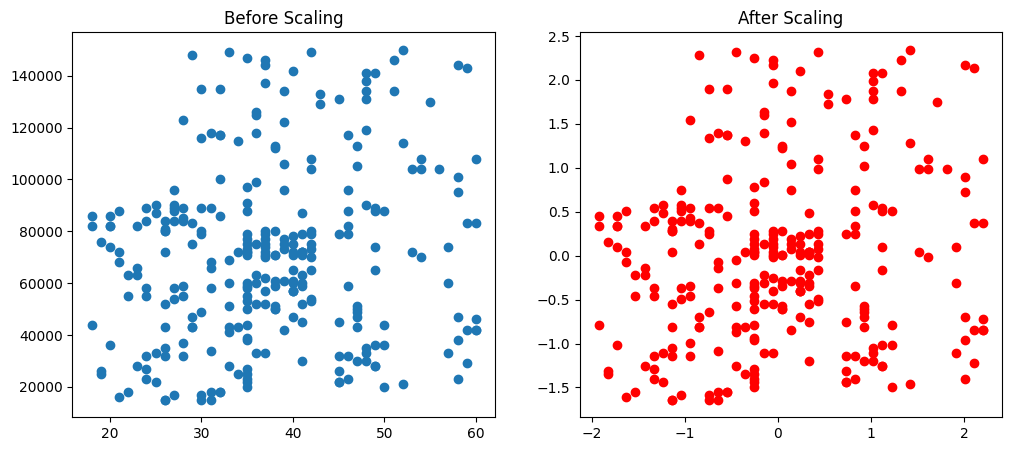

In [15]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.scatter(X_train["Age"],X_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color="red")
ax2.set_title("After Scaling")
plt.show()

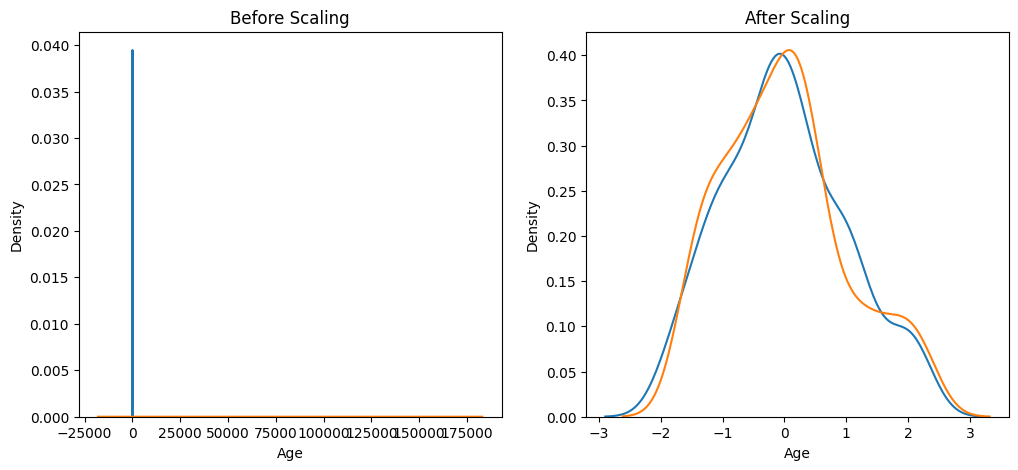

In [16]:
fig, (ax1 ,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("Before Scaling")
ax2.set_title("After Scaling")
sns.kdeplot(X_train["Age"],ax=ax1)
sns.kdeplot(X_train["EstimatedSalary"],ax=ax1)

sns.kdeplot(X_train_scaled["Age"],ax=ax2)
sns.kdeplot(X_train_scaled["EstimatedSalary"],ax=ax2)
plt.show()
#pdfs

#### Comparison of Distribution

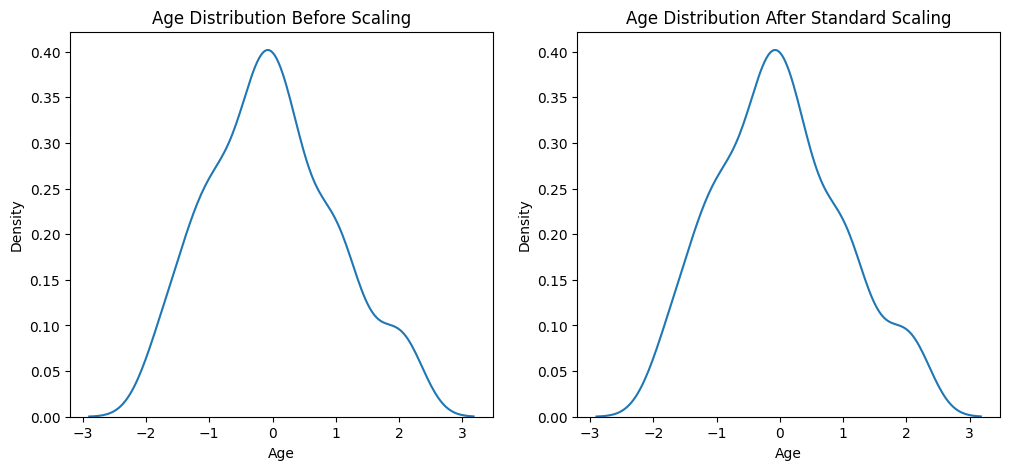

In [17]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(X_train_scaled["Age"],ax=ax1)

# after scaling
ax2.set_title("Age Distribution After Standard Scaling")
sns.kdeplot(X_train_scaled["Age"],ax=ax2)
plt.show()

#### Why Scaling is important?

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [20]:
# Train the model first
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled,y_train)

# Then predict
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)


In [21]:
from sklearn.metrics import accuracy_score

In [22]:
print("Actual Score",accuracy_score(y_test,y_pred))
print("Scaled Score",accuracy_score(y_test,y_pred_scaled))

Actual Score 0.85
Scaled Score 0.85


In [23]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()


In [26]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [27]:
y_pred=dt.predict(X_test)
y_pred_scaled=dt_scaled.predict(X_test_scaled)

In [28]:
print("Actual Score",accuracy_score(y_test,y_pred))
print("Scaled Score",accuracy_score(y_test,y_pred_scaled))

Actual Score 0.8583333333333333
Scaled Score 0.8333333333333334


#### Effect of outlier

In [31]:
df = pd.concat([
    df,
    pd.DataFrame({
        "Age": [5, 90, 95],
        "EstimatedSalary": [1000, 250000, 350000],
        "Purchased": [0, 1, 1]
    })
], ignore_index=True)

In [32]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


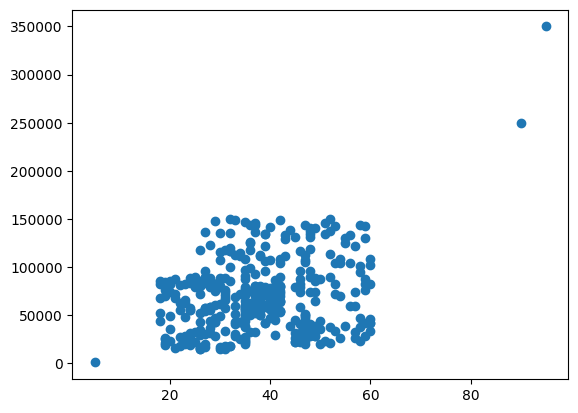

In [33]:
plt.scatter(df["Age"],df["EstimatedSalary"])

In [35]:
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(df.drop("Purchased",axis=1),df["Purchased"],test_size=0.3,random_state=0)

In [36]:
X_train.shape, X_test.shape

((282, 2), (121, 2))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [40]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

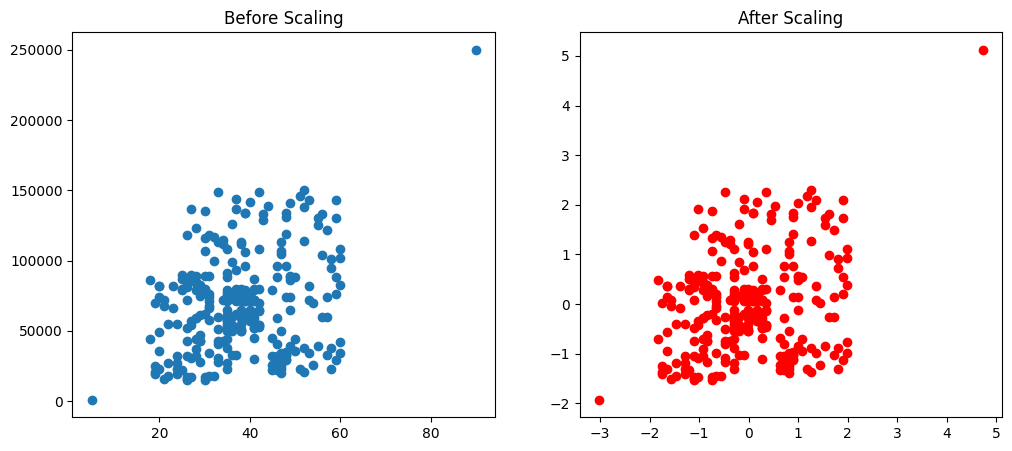

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.scatter(X_train["Age"],X_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color="red")
ax2.set_title("After Scaling")
plt.show()

Observation :

Outiler behavior still remains same we have to explicitly handle outliers.
